<a href='https://www.darshan.ac.in/'> <img src='https://www.darshan.ac.in/Content/media/DU_Logo.svg' width="250" height="300"/></a>
<pre>
<center><b><h1>Machine Learning & Deep Learning</b></center>

<center><b><h1>Lab - 6</b></center>    
<pre>    

# SVR

# Importing the libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVR

# Read World bank CSV

In [3]:
df = pd.read_csv("./WorldBank.csv")

In [4]:
df.head()

,Country Name,Country Code,Indicator Name,Indicator Code,1960,1961,1962,1963,1964,1965,...,2011,2012,2013,2014,2015,2016,2017,2018,2019,2020
0,India,IND,Export value index (2000 = 100),TX.VAL.MRCH.XD.WD,NaN,NaN,NaN,NaN,NaN,NaN,...,714.748450,700.408454,742.928128,761.441742,632.269428,624.224980,706.102795,766.360840,NaN,NaN
1,India,IND,Insurance and financial services (% of commerc...,TX.VAL.INSF.ZS.WT,NaN,NaN,NaN,NaN,NaN,NaN,...,6.403614,5.246771,5.729495,5.060904,4.706801,4.471147,3.760466,3.921611,3.438072,NaN
2,India,IND,"Merchandise imports by the reporting economy, ...",TM.VAL.MRCH.RS.ZS,4.983551,6.48805,10.124611,9.451370,10.529480,10.891125,...,0.755066,0.273842,0.440954,1.514439,2.228351,2.270593,1.770314,0.535419,NaN,NaN
3,India,IND,Food imports (% of merchandise imports),TM.VAL.FOOD.ZS.UN,NaN,NaN,17.080013,15.197912,16.863038,22.008132,...,3.741041,4.048246,3.895215,4.458509,5.758038,6.505293,6.137617,4.156488,4.248261,NaN
4,India,IND,Share of tariff lines with international peaks...,TM.TAX.MRCH.IP.ZS,NaN,NaN,NaN,NaN,NaN,NaN,...,8.434346,8.641136,8.576307,NaN,5.802677,7.707811,8.288774,9.111423,NaN,NaN


# Perform conditional selection to find - Population ages 15-64 (% of total population)

In [5]:
data = df[df['Indicator Name']== 'Population ages 15-64 (% of total population)']
data.head()
india = data[data['Country Name']=='India']
india

,Country Name,Country Code,Indicator Name,Indicator Code,1960,1961,1962,1963,1964,1965,...,2011,2012,2013,2014,2015,2016,2017,2018,2019,2020
9,India,IND,Population ages 15-64 (% of total population),SP.POP.1564.TO.ZS,56.49748,56.177532,55.807455,55.461664,55.248939,55.211351,...,64.429404,64.805519,65.208489,65.59598,65.944164,66.274262,66.538187,66.766743,67.003811,NaN


# Divide the data into input and output

In [13]:
x = india.columns[4:].astype(int).values.reshape(-1,1)
y = india.iloc[0,4:].values

In [14]:
x

array([[1960],
       [1961],
       [1962],
       [1963],
       [1964],
       [1965],
       [1966],
       [1967],
       [1968],
       [1969],
       [1970],
       [1971],
       [1972],
       [1973],
       [1974],
       [1975],
       [1976],
       [1977],
       [1978],
       [1979],
       [1980],
       [1981],
       [1982],
       [1983],
       [1984],
       [1985],
       [1986],
       [1987],
       [1988],
       [1989],
       [1990],
       [1991],
       [1992],
       [1993],
       [1994],
       [1995],
       [1996],
       [1997],
       [1998],
       [1999],
       [2000],
       [2001],
       [2002],
       [2003],
       [2004],
       [2005],
       [2006],
       [2007],
       [2008],
       [2009],
       [2010],
       [2011],
       [2012],
       [2013],
       [2014],
       [2015],
       [2016],
       [2017],
       [2018],
       [2019],
       [2020]])

In [15]:
y

array([np.float64(56.49748004), np.float64(56.17753236),
       np.float64(55.80745463), np.float64(55.46166361),
       np.float64(55.24893881), np.float64(55.21135053),
       np.float64(55.09090078), np.float64(55.15534672),
       np.float64(55.34507283), np.float64(55.57014408),
       np.float64(55.78194745), np.float64(55.85676846),
       np.float64(55.95268174), np.float64(56.07247186),
       np.float64(56.23447551), np.float64(56.44405309),
       np.float64(56.49722595), np.float64(56.62068516),
       np.float64(56.78900152), np.float64(56.9691436),
       np.float64(57.1425581), np.float64(57.18105454),
       np.float64(57.22630775), np.float64(57.28875038),
       np.float64(57.39054366), np.float64(57.54142108),
       np.float64(57.55350984), np.float64(57.6545119),
       np.float64(57.81875323), np.float64(58.01501187),
       np.float64(58.22990246), np.float64(58.37403848),
       np.float64(58.5472698), np.float64(58.75605047),
       np.float64(59.012126), np.fl

# Plot scatter plot of Population ages 15-64 (% of total population)

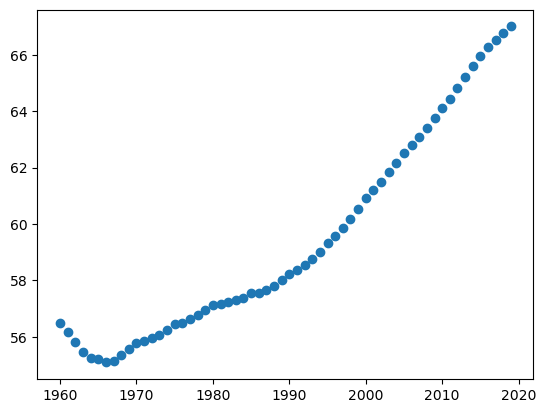

In [16]:
plt.scatter(x,y)

# Feature Scaling (Mandatory for SVR)**
SVR is highly sensitive to the range of data points. If we don't scale (normalize) the data, the model will fail to find the correct hyperplane.

In [21]:
sc_X = StandardScaler()
sc_y = StandardScaler()

X_train = sc_X.fit_transform(X_train)
X_test = sc_X.transform(X_test)

y_train = sc_y.fit_transform(y_train.reshape(-1,1))

# Splitting the dataset into the Training set and Test set

In [19]:
from sklearn.model_selection import train_test_split

X_train , X_test , y_train ,y_test = train_test_split(x,y,test_size = 0.2,random_state = 0)

# Fitting SVR on 3 Different Kernel on dataset

In [23]:
svr_linear = SVR(kernel = 'linear')
svr_linear.fit(X_train , y_train.ravel())

,kernel,'linear'
,degree,3
,gamma,'scale'
,coef0,0.0
,tol,0.001
,C,1.0
,epsilon,0.1
,shrinking,True
,cache_size,200
,verbose,False
,max_iter,-1


In [24]:
svr_poly = SVR(kernel = 'poly', degree =3)
svr_poly.fit(X_train , y_train.ravel())

,kernel,'poly'
,degree,3
,gamma,'scale'
,coef0,0.0
,tol,0.001
,C,1.0
,epsilon,0.1
,shrinking,True
,cache_size,200
,verbose,False
,max_iter,-1


In [25]:
svr_rbf = SVR(kernel = 'rbf')
svr_rbf.fit(X_train , y_train.ravel())

,kernel,'rbf'
,degree,3
,gamma,'scale'
,coef0,0.0
,tol,0.001
,C,1.0
,epsilon,0.1
,shrinking,True
,cache_size,200
,verbose,False
,max_iter,-1


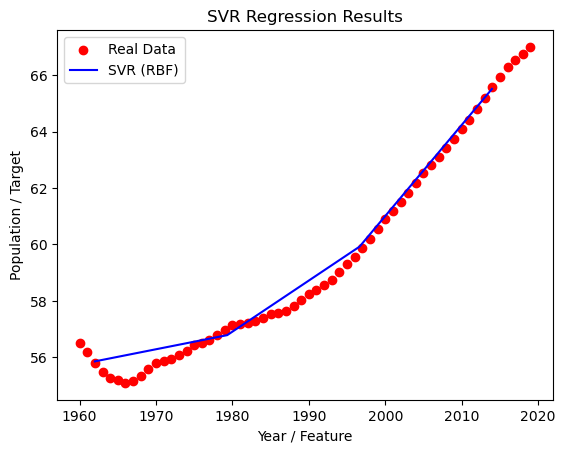

# Predict the x_test using 3 Kernel

In [26]:
y_pred_linear = svr_linear.predict(X_test)

In [27]:
y_pred_poly = svr_poly.predict(X_test)

In [28]:
y_pred_rbf = svr_rbf.predict(X_test)

array([57.55350984, 59.31657719, 67.00381119, 57.81875323, 55.85676846,
       55.80745463, 59.012126, 66.7667425, 60.90862046, 57.22630775,
       55.24893881, 55.78194745, 58.22990246, 61.18898716, 58.75605047,
       61.83084479, 63.74196691, 55.15534672], dtype=object)

array([57.73445326, 59.30206118, 64.8451716 , 57.99812952, 55.96479236,
       56.12587167, 59.06485884, 64.91876466, 60.76906052, 57.24445561,
       55.93360816, 55.89821768, 58.29641078, 61.1088798 , 58.84682535,
       61.81299688, 63.81278461, 55.81527994])

# Visualising the  results

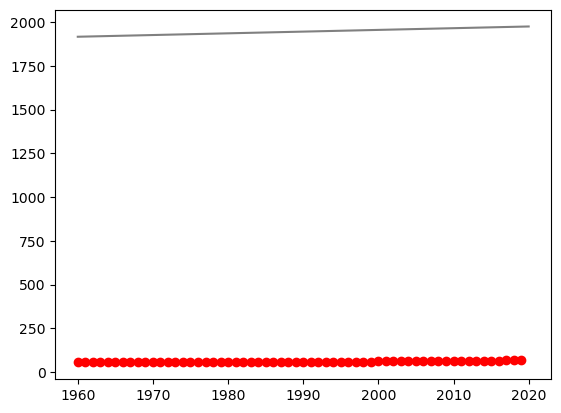

In [30]:
plt.scatter(x ,y, color='red',label ='Actual Data')
plt.plot(
    x,
    sc_y.inverse_transform(
        svr_linear.predict(
        sc_X.transform(x)
        ).reshape(-1,1)
    ),
    color ='grey',
    label = 'linear kernel'
)

### **Student Activity : Prediction**
**Task:** Predict the value for the Year **2025** (or value 6.5 in the demo data). 
Remember: You must transform the input before predicting, and inverse transform the output.

The predicted value for input 2025 is: 66.47
